# One Hot Encoding
[One Hot Encoding](https://medium.com/@WojtekFulmyk/one-hot-encoding-a-brief-explanation-8c5daec395e3)
* Text inputs are different sizes
* Zero Padding needs to be done in one-hot encoding which leads to unnecessary computation
* No relationship between the values

# Embedding
[Embedding](https://medium.com/@eugenesh4work/what-are-embeddings-and-how-do-it-work-b35af573b59e)
* Form of real value vector that encodes the meaning of the word such that the words that are closer in the vector space are expected to be similar in meaning

# Comparision of Embedding and One-hot encoding
* One-hot encoding gets a sparse vector while embeddings get a dense representation
* One-hot encoding doesn't understand the relationship and meaning between the words whereas embedding understands the meaning of the words
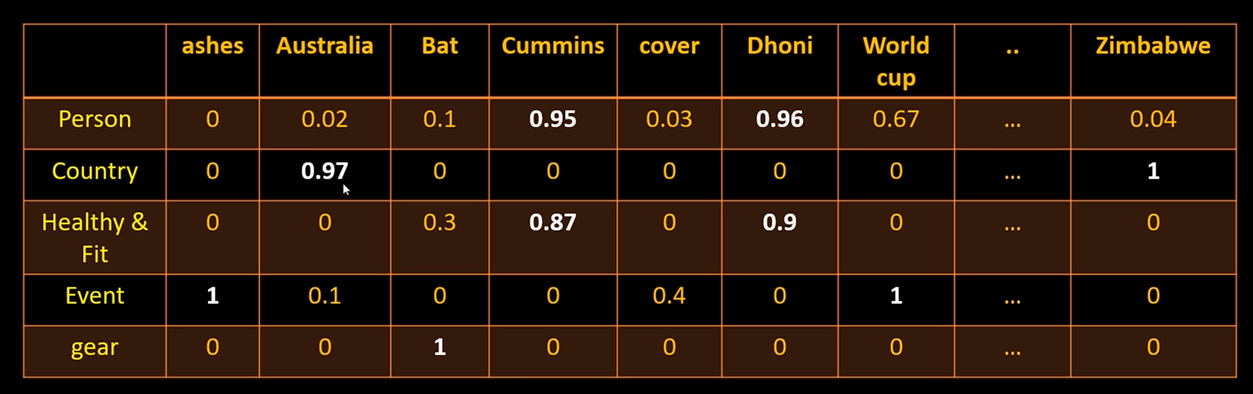

# RNN Introduction
* RNNs work best for sequential data (data that can be ordered)
* Neurons in RNNs give feedback to themselves and every other neuron in the same layer

# 4 types of RNNs
* Many to one
  * E.G. Detecting whether a twitter post is positive, negative, or neutral (Sentiment Analysis)
* One to Many
  * E.G. Image Captioning
* Many to Many
  * E.G. Language Translation, Music Note Generation
  * Variable Lengths
* One to One
  * E.G. Image Classification

# Why not ANNs
* ANNs only take fixed length data so you have to use zero-padding which increases the computational cost
* Sequence Info can't be processed with ANNs
* RNNs have memory while ANNs don't

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ln -s "/content/drive/MyDrive/DeepLearning/datasets" "/content/"

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd
df = pd.DataFrame({"review":["Movie was good", "Movie was bad", "Movie was not good", "Movie was not bad"],
                   "sentiment":[1, 0, 0, 1]})

In [ ]:
df.head()

,review,sentiment
0,Movie was good,1
1,Movie was bad,0
2,Movie was not good,0
3,Movie was not bad,1


Movie-[1, 0, 0, 0, 0]\
Was-[0, 1, 0, 0, 0]\
Not-[0, 0, 1, 0, 0]\
Good-[0, 0, 0, 1, 0]\
Bad-[0, 0, 0, 0, 1]

Movie was good-[[1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [0, 0, 0, 1, 0]] \
shape-(3, 5)&#129058;(timestep, number_of_features)

Batch Size, time step, input features
(3, 4, 5)

$X_1=X_{11}X_{12}X_{13}$\
$X_2=X_{21}X_{22}X_{23}$\
$X_3=X_{31}X_{32}X_{33}$\
$X_4=X_{41}X_{42}X_{43}$

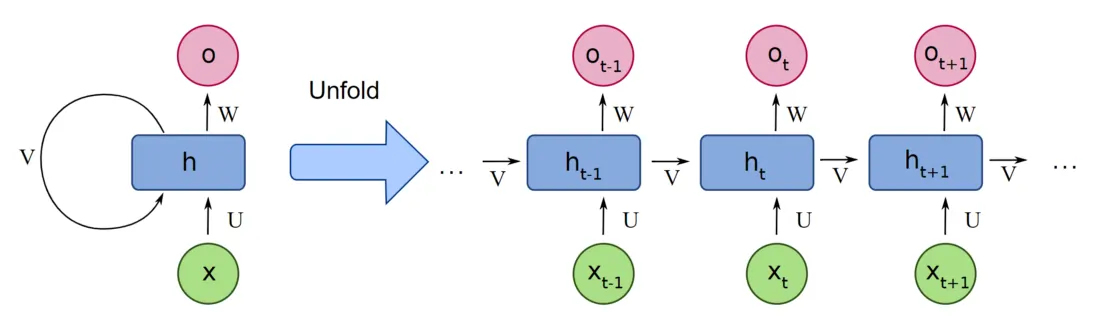

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Embedding, Flatten, Dropout

In [ ]:
model = Sequential()
model.add(SimpleRNN(3, input_shape=(4,5)))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_17 (SimpleRNN)       │ (None, 3)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.get_weights()[0].shape

(5, 3)

In [ ]:
model.get_weights()[0]

array([[-0.35296172, -0.41095915,  0.08979148],
       [-0.10972202, -0.06117135, -0.42698854],
       [ 0.6806018 ,  0.52543133, -0.57891357],
       [ 0.680648  , -0.3294081 ,  0.7524788 ],
       [-0.2781489 , -0.30575275,  0.17990774]], dtype=float32)

In [ ]:
model.get_weights()[1].shape

(3, 3)

In [ ]:
model.get_weights()[1]

array([[-0.62991154, -0.75753933, -0.17130616],
       [ 0.73512787, -0.51037085, -0.44621605],
       [-0.25059655,  0.40700853, -0.8783766 ]], dtype=float32)

In [ ]:
model.get_weights()[2].shape

(3,)

In [ ]:
model.get_weights()[2]

array([0., 0., 0.], dtype=float32)

In [ ]:
model.get_weights()[3].shape

(3, 1)

In [ ]:
model.get_weights()[3]

array([[-0.62619376],
       [ 0.7111076 ],
       [-1.1153622 ]], dtype=float32)

In [ ]:
model.get_weights()[4].shape

(1,)

In [ ]:
model.get_weights()[4]

array([0.], dtype=float32)

# Problems with RNNs
* Have short term memory
* RNNs have unstable gradient (doesn't have stable training)
* Has a problem of long term dependancies

# Homework
* Look at these:
  * Exponentially Weighted Average
  * SGD with Momentum
  * Nestrove Accelerated Gradient
  * AdaGrad
  * RMSProp
  * Adam

In [ ]:
document = ["Go India", "India is going to win", "Wow Kohli", "Hip hip hooray", "Lets go India", "Lets go Dhoni", "Lets go Rohit", "India will win for sure"]

go
india
is
going
to
win
wow
kohli
hip
hooray
lets
dhoni
rohit
will
for
sure

In [ ]:
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(document)

In [ ]:
tokenizer.word_index

{'<OOV>': 1,
 'go': 2,
 'india': 3,
 'lets': 4,
 'win': 5,
 'hip': 6,
 'is': 7,
 'going': 8,
 'to': 9,
 'wow': 10,
 'kohli': 11,
 'hooray': 12,
 'dhoni': 13,
 'rohit': 14,
 'will': 15,
 'for': 16,
 'sure': 17}

In [ ]:
tokenizer.word_counts

OrderedDict([('go', 4),
             ('india', 4),
             ('is', 1),
             ('going', 1),
             ('to', 1),
             ('win', 2),
             ('wow', 1),
             ('kohli', 1),
             ('hip', 2),
             ('hooray', 1),
             ('lets', 3),
             ('dhoni', 1),
             ('rohit', 1),
             ('will', 1),
             ('for', 1),
             ('sure', 1)])

In [ ]:
sequence=tokenizer.texts_to_sequences(document)
sequence

[[2, 3],
 [3, 7, 8, 9, 5],
 [10, 11],
 [6, 6, 12],
 [4, 2, 3],
 [4, 2, 13],
 [4, 2, 14],
 [3, 15, 5, 16, 17]]

In [ ]:
from keras.utils import pad_sequences
sequence=pad_sequences(sequence, padding="post")

NameError: name 'sequence' is not defined

In [ ]:
sequence

array([[ 2,  3,  0,  0,  0],
       [ 3,  7,  8,  9,  5],
       [10, 11,  0,  0,  0],
       [ 6,  6, 12,  0,  0],
       [ 4,  2,  3,  0,  0],
       [ 4,  2, 13,  0,  0],
       [ 4,  2, 14,  0,  0],
       [ 3, 15,  5, 16, 17]], dtype=int32)

In [ ]:
from keras.datasets import imdb


In [ ]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 22665,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 21631,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 19193,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 10311,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 31050,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 12118,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5

In [ ]:
len(X_train[0])

218

In [ ]:
vocablist = list()
for review in X_test1+X_train1:
  vocablist+=(str(review).lower()).split()
print(f"The vocabulary size is: {len(set(vocablist))}")

NameError: name 'X_test1' is not defined

In [ ]:
len(vocablist)

NameError: name 'vocablist' is not defined

In [ ]:
X_train = pad_sequences(X_train, maxlen=50, padding="post")
X_test = pad_sequences(X_test, maxlen=50, padding="post")

In [ ]:
!pip install tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import SimpleRNN, Dropout, Dense, BatchNormalization

In [ ]:
model = Sequential()
model.add(SimpleRNN(1024, return_sequences=True, input_shape=(50, 1)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(SimpleRNN(512, return_sequences=True)) # Added return_sequences=True
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(SimpleRNN(256, return_sequences=True)) # Added return_sequences=True
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(SimpleRNN(128, return_sequences=True)) # Added return_sequences=True
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(SimpleRNN(64, return_sequences=True)) # Added return_sequences=True
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(SimpleRNN(32, return_sequences=False)) # Added return_sequences=True
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_40 (SimpleRNN)       │ (None, 50, 1024)       │     1,050,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 50, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_41 (SimpleRNN)       │ (None, 50, 512)        │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 50, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_42 (SimpleRNN)       │ (None, 50, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_43 (SimpleRNN)       │ (None, 50, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_44 (SimpleRNN)       │ (None, 50, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_45 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 128)            │             

 Total params: 2,158,945 (8.24 MB)

 Trainable params: 2,154,913 (8.22 MB)

 Non-trainable params: 4,032 (15.75 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate = 1e-3), metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.5076 - loss: 0.6963 - val_accuracy: 0.5010 - val_loss: 0.6936
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.5107 - loss: 0.6941 - val_accuracy: 0.4970 - val_loss: 0.6939
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.4916 - loss: 0.6943 - val_accuracy: 0.5012 - val_loss: 0.6932
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.5037 - loss: 0.6938 - val_accuracy: 0.4938 - val_loss: 0.6925
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.5104 - loss: 0.6936 - val_accuracy: 0.5124 - val_loss: 0.6942
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.5003 - loss: 0.6935 - val_accuracy: 0.4938 - val_loss: 0.6931
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.5000 - loss: 0.6935 - val_accuracy: 0.5166 - val_loss: 0.6920
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.4950 - loss: 0.6931 - 

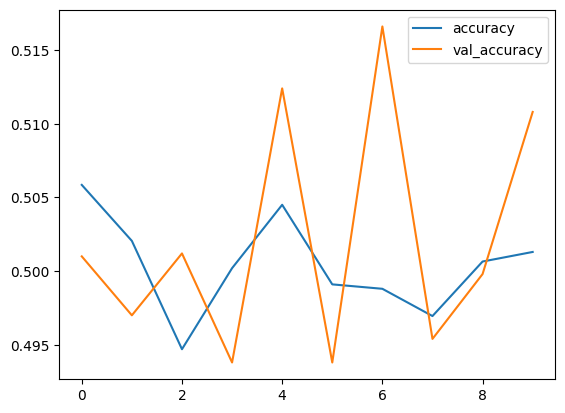

In [ ]:
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.show()

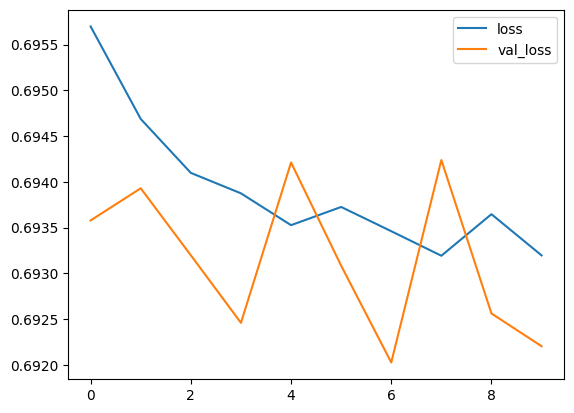

In [ ]:
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.legend()
plt.show()

In [ ]:
model.save("datasets/models/RNNIMDBmodelv2.h5")

In [ ]:
from tensorflow import keras
from keras.models import load_model

In [ ]:
model = load_model("datasets/models/RNNIMDBmodelv2.h5")

In [ ]:
word_indices=imdb.get_word_index()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred=[1 if y_pred>=0.5 else 0 for y_pred in y_pred]

In [ ]:
y_pred

In [ ]:
y_test

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

In [ ]:
y_pred[219]

In [ ]:
y_test[219]

# Homework
* Extend the code so that you can take review inputs from the user and test it
* Improve the model by adding more layers and increasing # of neurons

In [ ]:
#@title Test Review
def encode_review(review, word_index):
    return [word_index.get(word.lower(), 2) for word in review.split()]

input_review = "" # @param {"type":"string","placeholder":"Best movie I have ever seen"}
encoded_review = [encode_review(input_review, word_indices)]
encoded_review = pad_sequences(encoded_review, maxlen=50, padding="post")
output=model.predict(encoded_review)[0][0]
if output>=0.5:
  print("Good review")
else:
  print("Bad Review")

In [ ]:
X_train

# RNNs with Word Embedding

In [ ]:
model = Sequential()
model.add(Embedding(93920, 2, input_length=50))
model.add(SimpleRNN(256, return_sequences=True))
model.add(Dropout(0.3))
model.add(SimpleRNN(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(SimpleRNN(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [ ]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

In [ ]:
plt.plot(history.history["accuracy"], label = "accuracy")
plt.plot(history.history["val_accuracy"], label = "val_accuracy")
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history["loss"], label = "loss")
plt.plot(history.history["val_loss"], label = "val_loss")
plt.legend()
plt.show()

# Conclusions
In terms of accuracy, the model with word embeddings is better than the other model without word embeddings.

Simple RNN Homework

In [ ]:
df = pd.read_csv("/content/twitter_training.csv")

In [ ]:
df

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...
